# EC-Earth CCN–CDNC Susceptibility Builder

**Scientific question:** Same susceptibility analysis as the NorESM builder (slope of d ln CDNC / d ln CCN, per level and pooled, with four estimators) but for **EC-Earth** output. EC-Earth needs extra handling because cloud/aerosol variables come from the IFS stream and pressure is a time-varying field that must be reduced to a `lev` coordinate.

**Input:** `/share/sabl0586/all_stations_EC-Earth_*.nc`  
**Output:** per-station susceptibility Dataset (OLS/ODR/Deming/PCA slopes).

---
*Collapse the `##` headers to skim: 1 Setup · 2 Fit functions · 3 EC-Earth loader · 4 Build · 5 Plots.*

## 1 · Setup and configuration

In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm


In [2]:
# Configuration
EC_PATH = "/share/sabl0586/all_stations_EC-Earth_PRCP2SZDST_ilevall_levs_4Peter.nc"
RADII   = np.arange(20, 51)        # CCN cutoff radii [nm]

# IFS variables to pull and their standardized names (paired 1:1).
# var54 (pressure) is handled separately by the loader, so it is NOT in this list.
ifs_vars       = ['var20', 'var22']        # var20=cloud droplet num, var22=cloud frac (for CDNC)
ifs_var_names  = ['var20', 'var22']        # keep raw names; loader builds CDNC = var20/var22

# Size-distribution diameter grid [nm], log-spaced
D_GRID = xr.DataArray(np.logspace(-0.5, 3, num=200), dims=['D'],
                      coords={'D': np.logspace(-0.5, 3, num=200)})

## 2 · Load dataset and station list

In [3]:
ds = xr.open_dataset(EC_PATH, chunks={})
stations = ds["station"].values

## 3 · Build susceptibility across stations

`Function.ECearthExtract_Dask` does the heavy lifting internally: it loads the 7 aerosol modes, converts radii to nm, builds **CDNC = var20/var22** (where var22>0). The interpolation of the IFS variables onto EC-Earth's model levels is broken in the function. This cell interpolates the IFS pressure levels onto the mean pressure levels of each station **ec_p_all and ifs_p_all are the mean level by station** The resulting levels are integers from 0 to 34. `Function.ECEarthERF` then integrates the modes into CCN at each cutoff radius, and the shared susceptibility functions do the fits.

This replaces the earlier hand-rolled IFS-regrid cells — the loader already performs that regrid (collapse redundant `lev`, interp `lev_ifs`→`lev`), so it does not need to be done separately in the notebook.

In [5]:
import dask
dask.config.set(scheduler='synchronous')

all_stations = []
all_stationsCCN = []

for station in stations:
    # Loader does it all: regrids IFS onto 34 levels, builds CDNC (var22>=8640 mask),
    # returns the aerosol modes for CCN.
    EC_ds = Function.ECearthExtract_Dask(
        EC_PATH, station, ['var20', 'var22'], ['var20', 'var22'], D_GRID, PNSD=False
    )
    CCN_ds = Function.ECEarthERF(EC_ds, RADII)

    # Susceptibility fits (CCN and CDNC share the integer lev axis from the loader).
    cdnc = EC_ds['CDNC'].chunk({'time': -1})

    Level_susc_ds, Levels_CCN_ds = Function.susceptibility_by_level(CCN_ds, cdnc)
    Susceptibility_AllLevs       = Function.compute_allLev(CCN_ds, cdnc)

    Susceptibility_ds = xr.merge([Level_susc_ds, Susceptibility_AllLevs])
    all_stations.append(Susceptibility_ds.assign_coords(station=station))
    all_stationsCCN.append(Levels_CCN_ds.assign_coords(station=station))

Susceptibility_all = xr.concat(all_stations, dim='station')
CCN_all = xr.concat(all_stationsCCN, dim='station')

In [6]:
# Force evaluation of the lazy graph -> in-memory for plotting.
Susceptibility_all = Susceptibility_all.compute()
CCN_all = CCN_all.compute()

## 4 · Plots

In [7]:
Susceptibility_all 

<xarray.Dataset> Size: 1MB
Dimensions:                     (station: 15, radius: 31, lev: 34)
Coordinates:
  * station                     (station) <U8 480B 'ZEP' 'SMR-II' ... 'Maldives'
  * radius                      (radius) int64 248B 20 21 22 23 ... 47 48 49 50
    lev_ifs                     (lev) float64 272B 1.0 2.0 3.0 ... 33.0 34.0
    pressure_hPa                (station, lev) float32 2kB 994.6 ... 0.1071
  * lev                         (lev) float64 272B 1.0 2.0 3.0 ... 33.0 34.0
Data variables: (12/16)
    OLS slope                   (station, radius, lev) float64 126kB nan ... nan
    OLS intercept               (station, radius, lev) float64 126kB nan ... nan
    ODR slope                   (station, radius, lev) float64 126kB nan ... nan
    ODR intercept               (station, radius, lev) float64 126kB nan ... nan
    Deming slope                (station, radius, lev) float64 126kB nan ... nan
    Deming intercept            (station, radius, lev) float64 126kB nan ... nan
    ...                          ...
    All_Level_TLS_slope         (station, radius) float64 4kB 0.5311 ... 0.809
    All_Level_TLS_intercept     (station, radius) float64 4kB -2.449 ... -4.421
    All_Level_Deming_slope      (station, radius) float64 4kB 0.4845 ... 0.805
    All_Level_Deming_intercept  (station, radius) float64 4kB -2.088 ... -4.388
    All_Level_PCA_slope         (station, radius) float64 4kB 0.2146 ... 0.2745
    All_Level_PCA_intercept     (station, radius) float64 4kB 0.002519 ... 0....

OLS


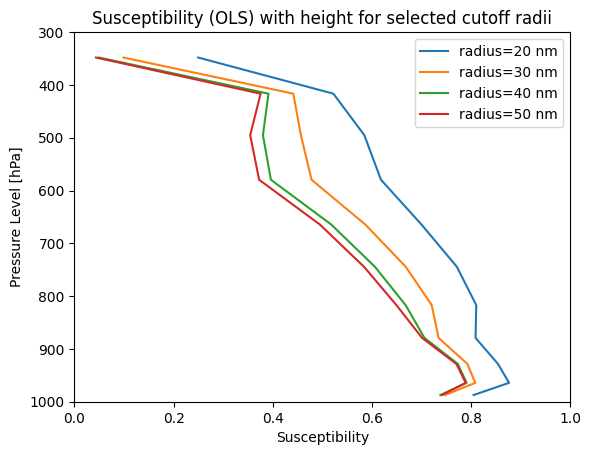

ODR


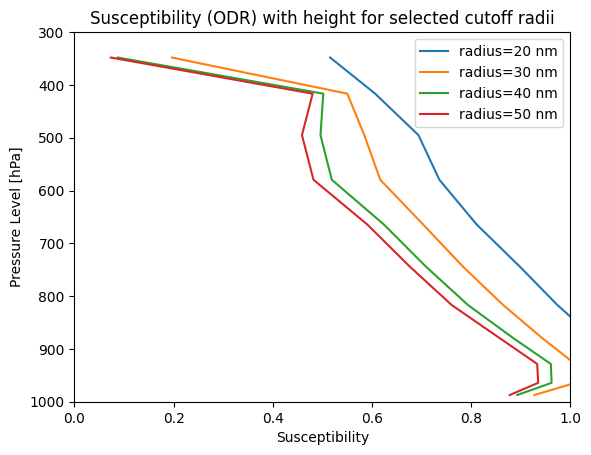

Deming


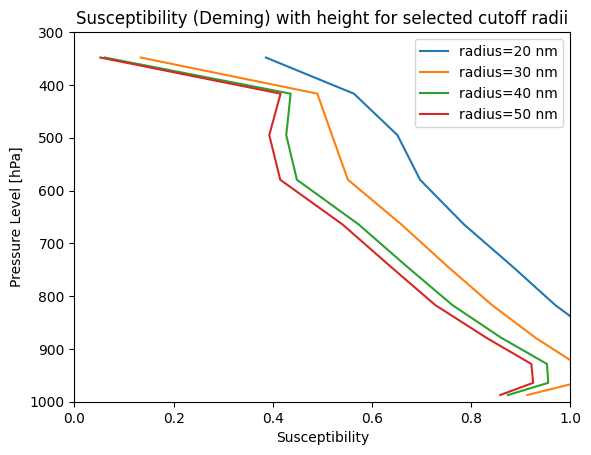

PCA


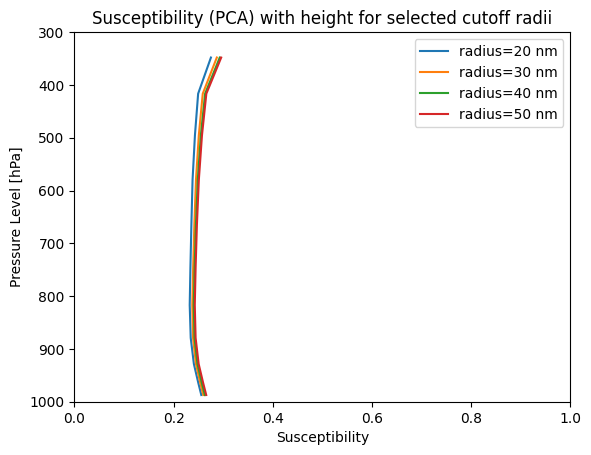

In [9]:
def PLOTSusc_by_Level(ds = Susceptibility_all, Fit = 'OLS', station = 'SMR-II'):
    radii_to_plot = [20, 30, 40, 50]
    for r in radii_to_plot:
        ds[f'{Fit} slope'].sel(radius=r, station = station).plot(
            y='pressure_hPa', 
            yincrease=False, 
            ylim=[1000, 300],
            xlim = [0,1],
            label=f'radius={r} nm'
        )
    
    plt.legend()
    plt.xlabel("Susceptibility")
    plt.ylabel("Pressure Level [hPa]")
    plt.title(f"Susceptibility ({Fit}) with height for selected cutoff radii")
    plt.show()

FitType = ['OLS', 'ODR', 'Deming', 'PCA']
for fit in FitType:
    print(fit)
    PLOTSusc_by_Level(Susceptibility_all, Fit = fit, station = 'SMR-II')

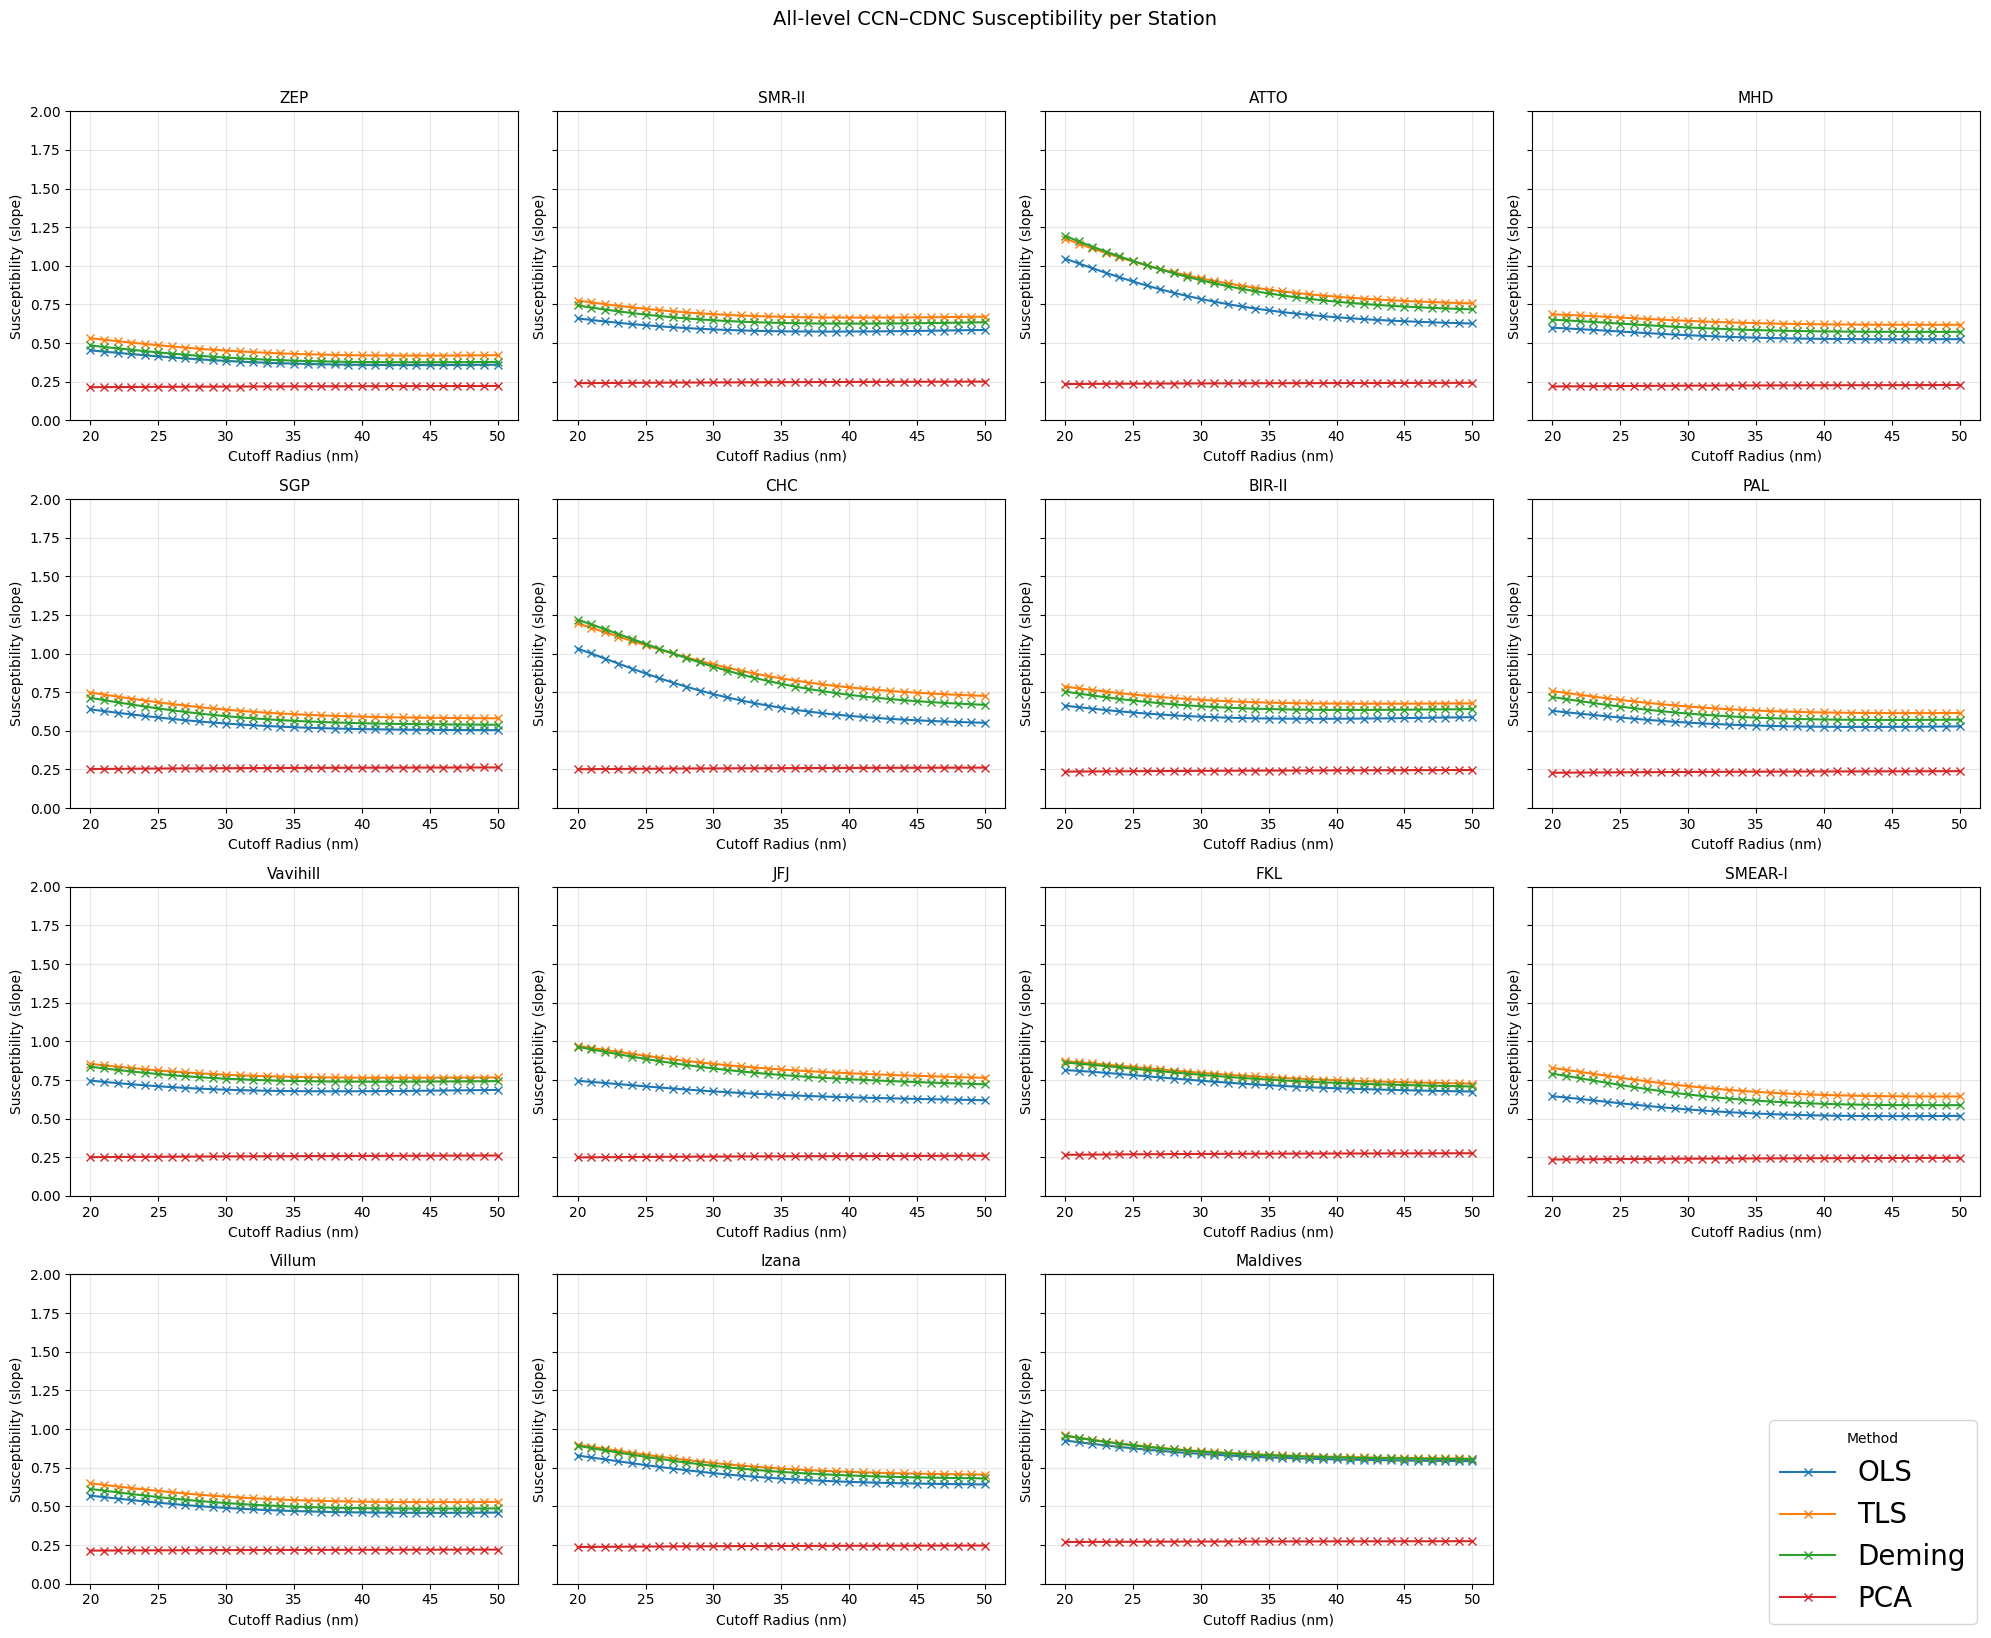

In [10]:
stations = Susceptibility_all.station.values
methods = ["OLS", "TLS", "Deming", "PCA"]

# Define number of columns and rows dynamically
ncols = 4
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 4 * nrows),
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):
    ax = axes[i]
    for method in methods:
        var_name = f"All_Level_{method}_slope"
        if var_name in Susceptibility_all:
            Susceptibility_all[var_name].sel(station=station).plot(
                ax=ax, marker='x', label=method
            )
    ax.set_title(f"{station}", fontsize=11)
    ax.set_xlabel("Cutoff Radius (nm)")
    ax.set_ylabel("Susceptibility (slope)")
    ax.set_ylim(0, 2)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(len(stations), len(axes)):
    axes[j].set_visible(False)

# Add a global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Method", loc="lower right", fontsize=20)

fig.suptitle("All-level CCN–CDNC Susceptibility per Station", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [11]:
def plot_station_fits_from_dataset(Susceptibility_all, station, CCN_ds, EC_ds, radius=35, methods=None):
    """
    Plot Nd vs CCN (log–log) with precomputed fits from Susceptibility_all.
    No refitting is done here.
    """
    if methods is None:
        methods = ["OLS", "TLS", "Deming", "PCA"]

    # --- Prepare data ---
    x = CCN_all['CCN'].sel(radius=radius, station = station).to_numpy().ravel()/1E6
    y = CCN_all["CDNC"].sel(station = station).to_numpy().ravel()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]

    fits = []

    # --- Get slopes/intercepts from dataset ---
    for method in methods:
        slope_var = f"All_Level_{method}_slope"
        intercept_var = f"All_Level_{method}_intercept"

        if slope_var in Susceptibility_all and intercept_var in Susceptibility_all:
            slope = Susceptibility_all[slope_var].sel(station=station, radius=radius).compute().item()
            intercept = Susceptibility_all[intercept_var].sel(station=station, radius=radius).compute().item()

            fits.append({
                "slope": slope,
                "intercept": intercept,
                "label": f"{method}: slope={slope:.2f}",
                "style": {
                    "OLS": "r-",
                    "TLS": "g--",
                    "Deming": "b-.",
                    "PCA": "m:",
                }.get(method, "k-")
            })

    # --- Plot all fits on a single hexbin plot ---
    fig, ax = Function.plot_hexbin_regression_multi(
        x, y,
        fits=fits,
        lims=(1, 1e4),
        title=f"{station}: CCN–CDNC Fits (radius={radius} nm)"
    )

    plt.tight_layout()
    return fig, ax

In [12]:
CCN_all.sel(station = 'SMR-II').CDNC.mean('time')

<xarray.DataArray 'CDNC' (lev: 34)> Size: 136B
array([       nan, 213.10541 , 184.64903 , 142.38983 , 110.56236 ,
        96.06716 ,  93.942184,  92.37948 ,  91.940895,  98.22293 ,
       107.28902 , 170.76013 ,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan], dtype=float32)
Coordinates:
    station       <U8 32B 'SMR-II'
    lev_ifs       (lev) float64 272B 1.0 2.0 3.0 4.0 5.0 ... 31.0 32.0 33.0 34.0
    pressure_hPa  (lev) float32 136B 998.9 987.3 964.2 ... 1.405 0.4877 0.1071
  * lev           (lev) float64 272B 1.0 2.0 3.0 4.0 5.0 ... 31.0 32.0 33.0 34.0

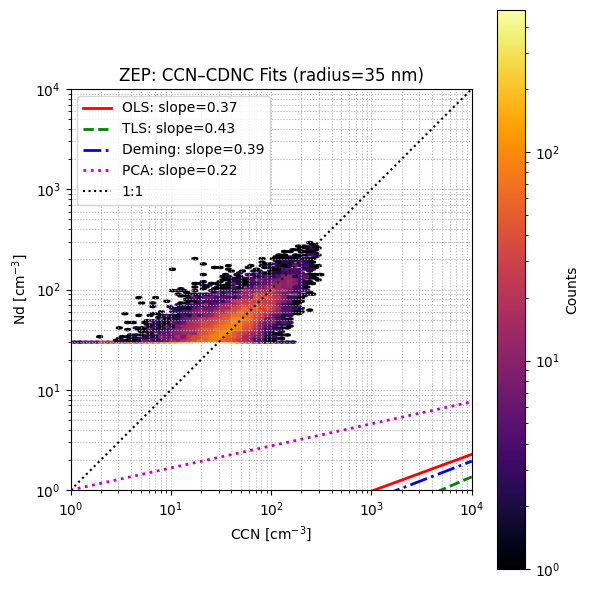

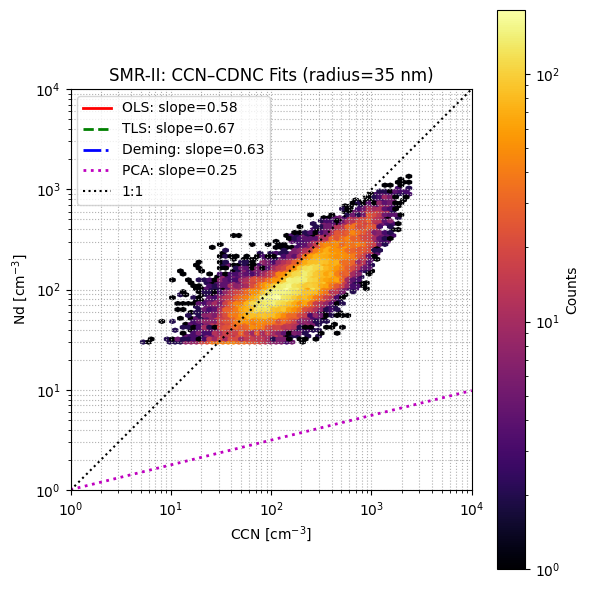

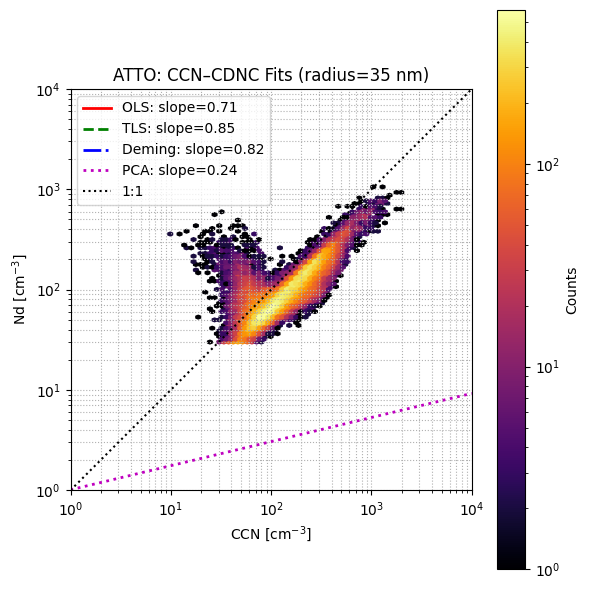

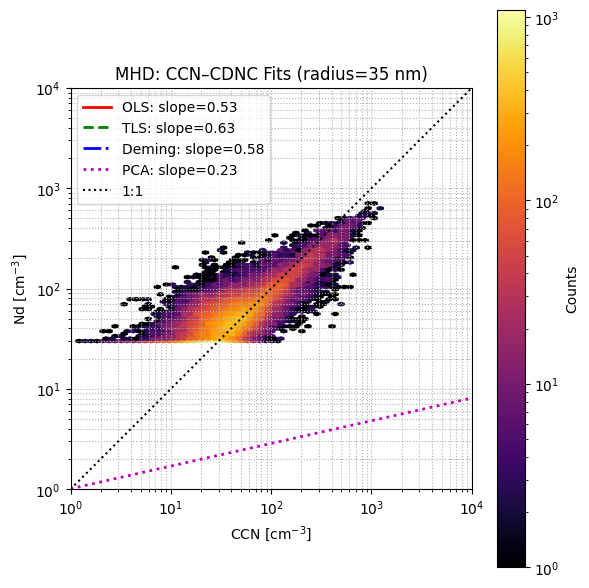

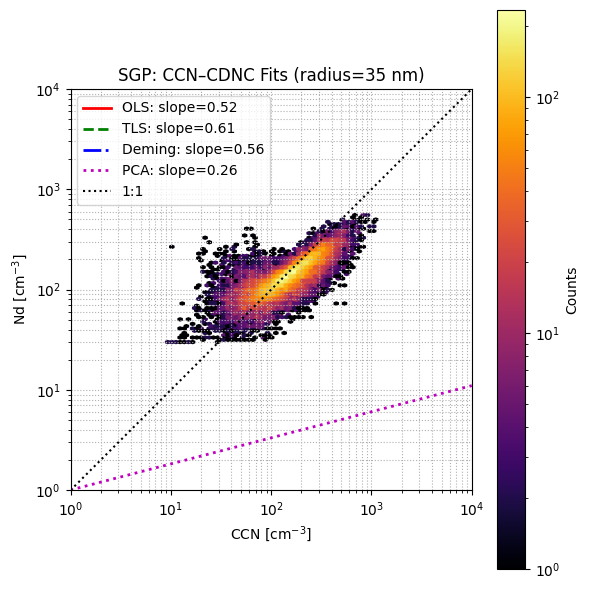

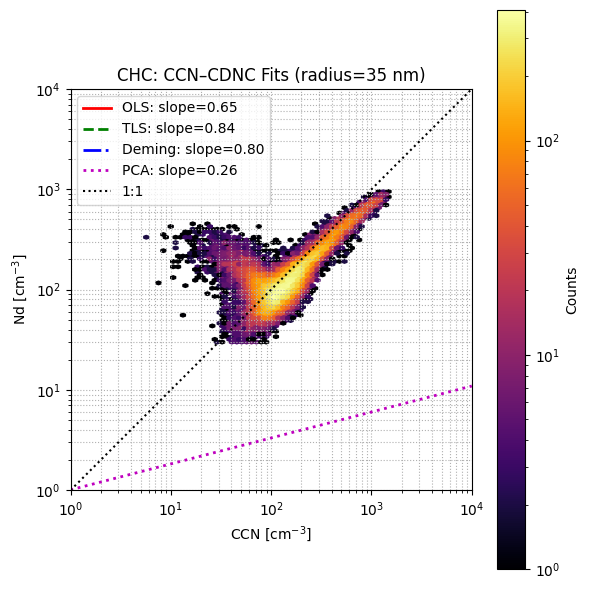

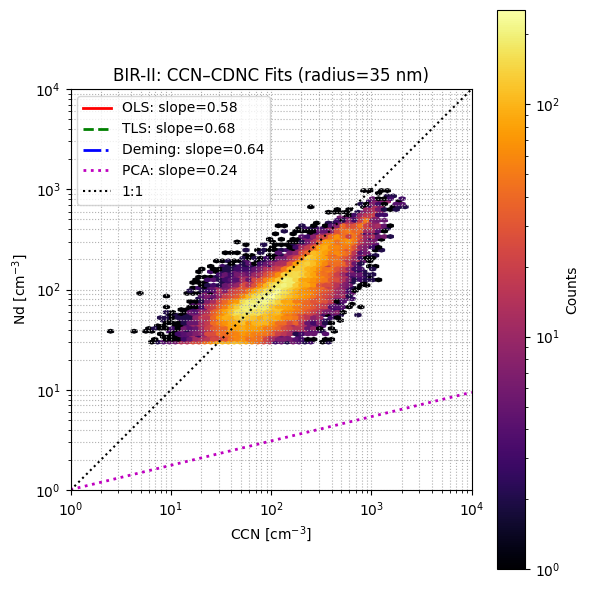

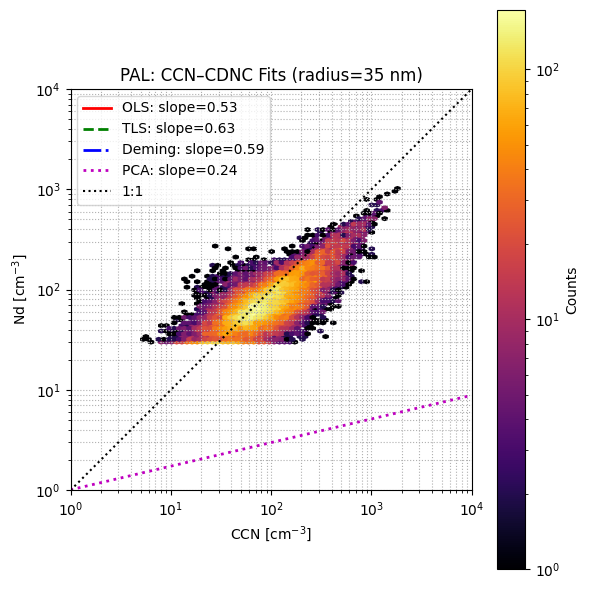

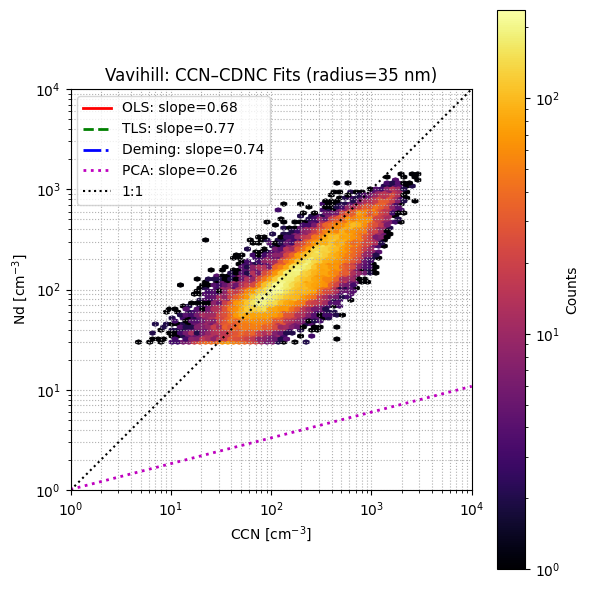

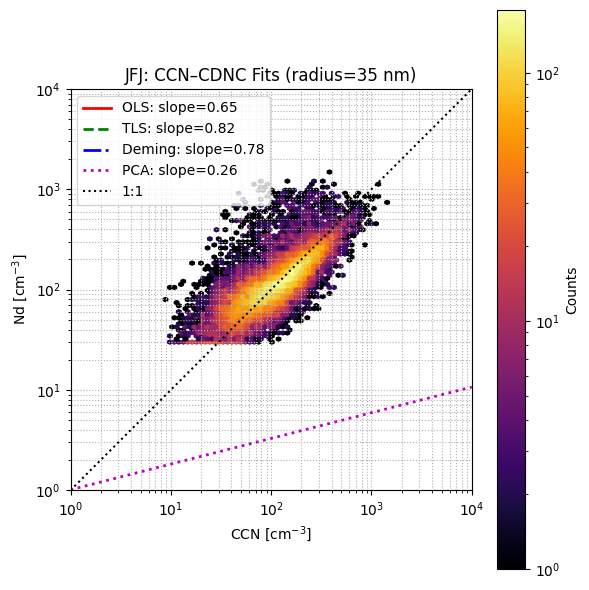

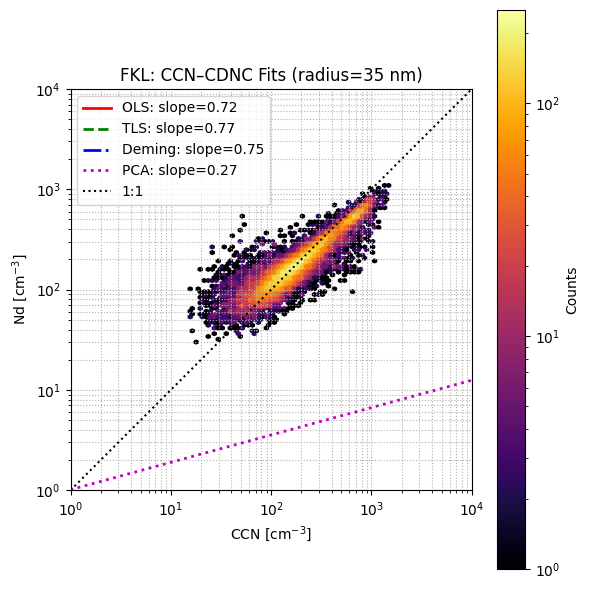

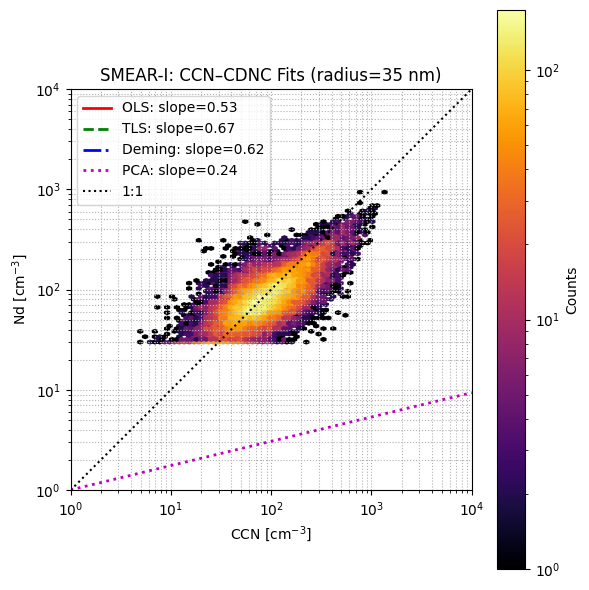

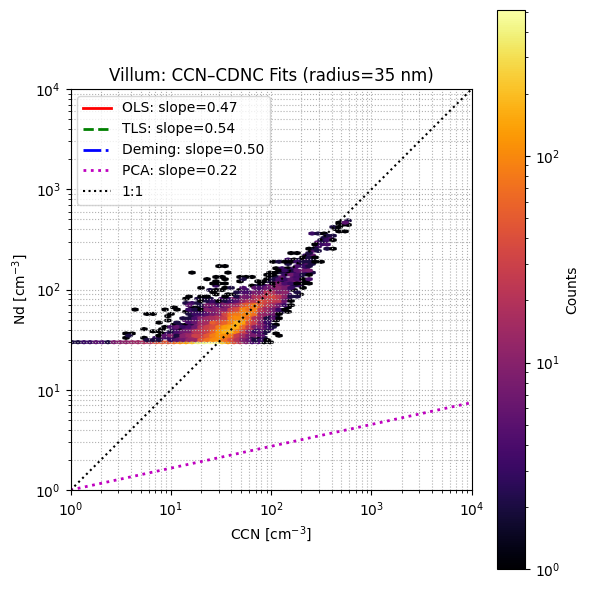

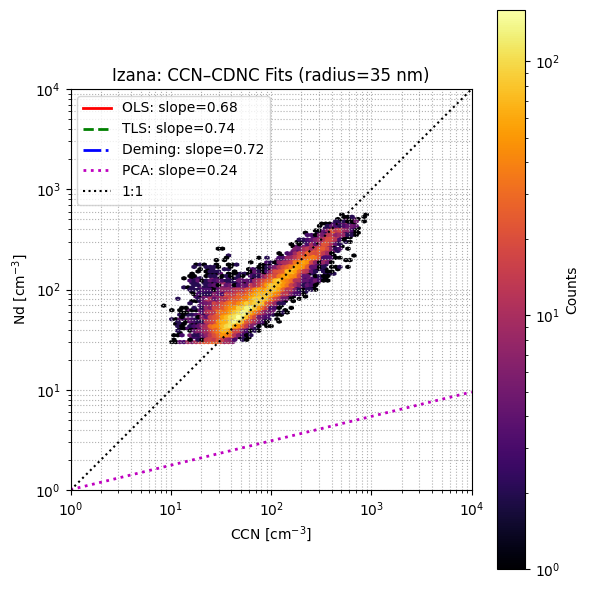

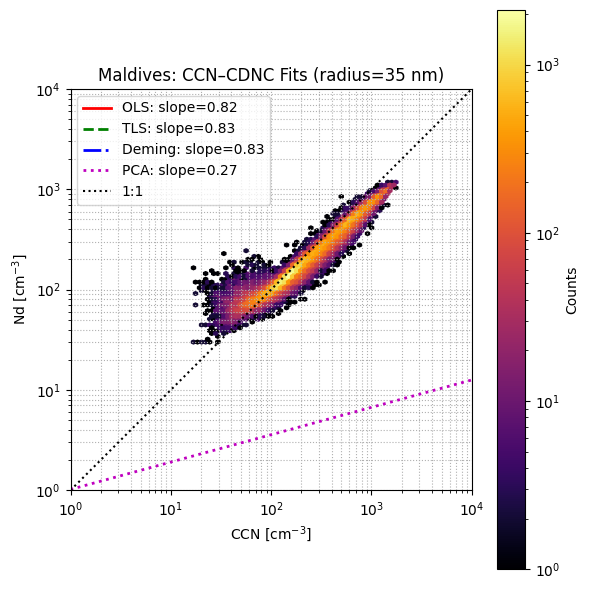

In [14]:
for station in stations:
    plot_station_fits_from_dataset(
        Susceptibility_all,
        station=station,
        CCN_ds=CCN_ds,
        EC_ds=EC_ds,
        radius=35
    )

In [13]:
CCN_all

<xarray.Dataset> Size: 8GB
Dimensions:       (station: 15, radius: 31, time: 61369, lev: 34)
Coordinates:
  * station       (station) <U8 480B 'ZEP' 'SMR-II' ... 'Izana' 'Maldives'
  * time          (time) datetime64[ns] 491kB 2012-01-01 ... 2019-01-01
    time_orig     (time) datetime64[ns] 491kB 2012-01-01T00:30:00 ... NaT
    lev_ifs       (lev) float64 272B 1.0 2.0 3.0 4.0 5.0 ... 31.0 32.0 33.0 34.0
    pressure_hPa  (station, lev) float32 2kB 994.6 983.1 960.1 ... 0.4877 0.1071
  * lev           (lev) float64 272B 1.0 2.0 3.0 4.0 5.0 ... 31.0 32.0 33.0 34.0
  * radius        (radius) int64 248B 20 21 22 23 24 25 26 ... 45 46 47 48 49 50
Data variables:
    CCN           (station, radius, time, lev) float64 8GB 4.323e+07 ... nan
    CDNC          (station, time, lev) float32 125MB nan nan nan ... nan nan nan

In [15]:
print("non-NaN slope count:", int(Susceptibility_all['OLS slope'].isel(station=0).count().values))
print("slope range:", float(Susceptibility_all['OLS slope'].min().values),
      "to", float(Susceptibility_all['OLS slope'].max().values))

non-NaN slope count: 310
slope range: -0.7874985606655596 to 2.8202810335328166
